# Task 2: Data Visualization

**Index:**
1. Load Engineered Data
2. Perplexity Comparison
3. 2D Scatter Plot Comparison
4. 3D Projection

In [1]:
import sys
import os
import time

# Add project root to path so src can be imported
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import visualization utilities
from src.visualization import (
    compute_tsne,
    plot_tsne_2d,
    plot_tsne_3d,
    plot_perplexity_comparison,
)

# Set plotting style
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

## 1. Load Engineered Data

In [2]:
# Load engineered train/val/test data and concatenate to full dataset
features_train = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_train.csv'))
targets_train = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_train.csv')).iloc[:, 0]

features_val = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_val.csv'))
targets_val = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_val.csv')).iloc[:, 0]

features_test = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_test.csv'))
targets_test = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_test.csv')).iloc[:, 0]

# Concatenate to full dataset
X = pd.concat([features_train, features_val, features_test], axis=0, ignore_index=True)
y = pd.concat([targets_train, targets_val, targets_test], axis=0, ignore_index=True)

print(f"Features shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts().sort_index().to_string())

Features shape: (4424, 61)
Target distribution:
Target
0    1421
1     794
2    2209


## 2. 2D Scatter Plot Comparison

In [3]:
# Define experiment parameters
perplexities = [10, 20, 30, 50]
results_2d = {}

for perp in perplexities:
    print(f"\n t-SNE with perplexity={perp}:")
    start = time.time()
    embedding = compute_tsne(X.values, perplexity=perp, n_components=2)
    elapsed = time.time() - start
    print(f"  Time elapsed: {elapsed:.1f}s")
    results_2d[perp] = embedding


 t-SNE with perplexity=10:
t-SNE done: perplexity=10, n_components=2, shape=(4424, 2)
  Time elapsed: 5.1s

 t-SNE with perplexity=20:
t-SNE done: perplexity=20, n_components=2, shape=(4424, 2)
  Time elapsed: 5.9s

 t-SNE with perplexity=30:
t-SNE done: perplexity=30, n_components=2, shape=(4424, 2)
  Time elapsed: 6.2s

 t-SNE with perplexity=50:
t-SNE done: perplexity=50, n_components=2, shape=(4424, 2)
  Time elapsed: 7.2s


Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03_tsne_2d_perplexity_comparison.png


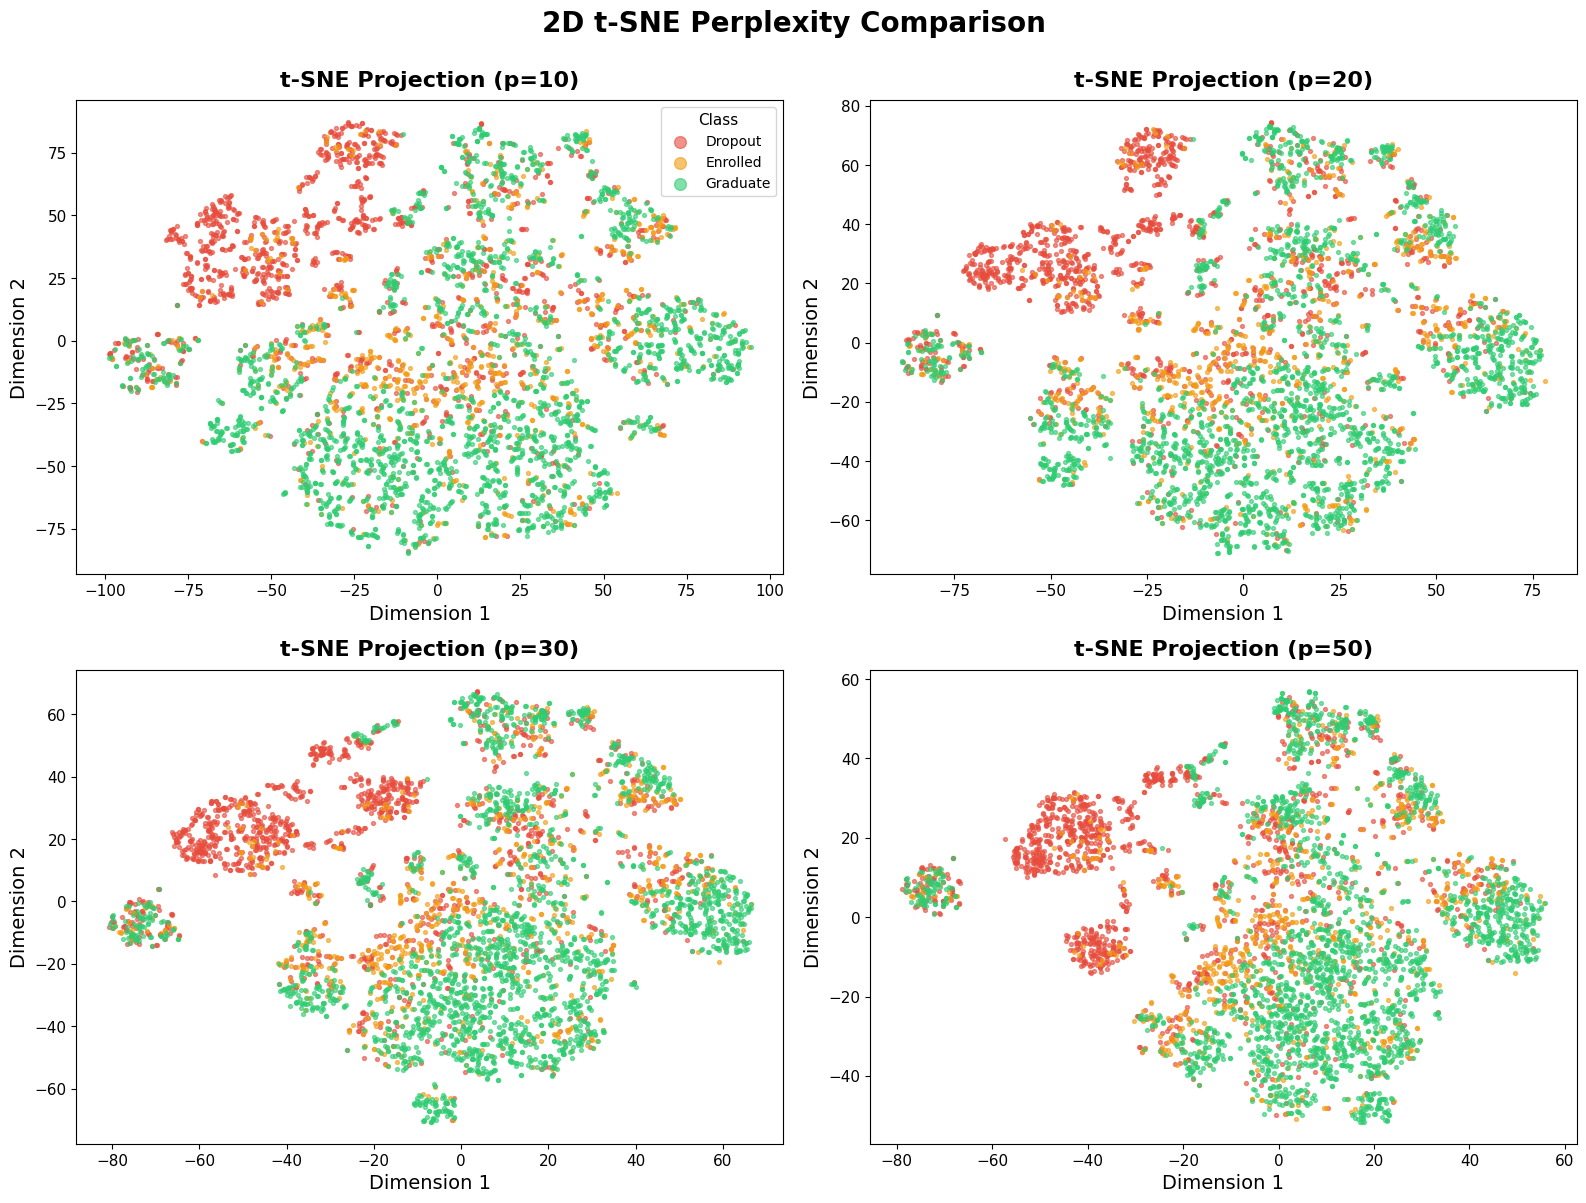

In [4]:
# Plot 2x2 perplexity comparison
save_path = os.path.join(project_root, "data", "plots", "03_tsne_2d_perplexity_comparison.png")
fig = plot_perplexity_comparison(results_2d, y.values, save_path=save_path)
plt.show()

Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03_tsne_2d_perplexity_best.png


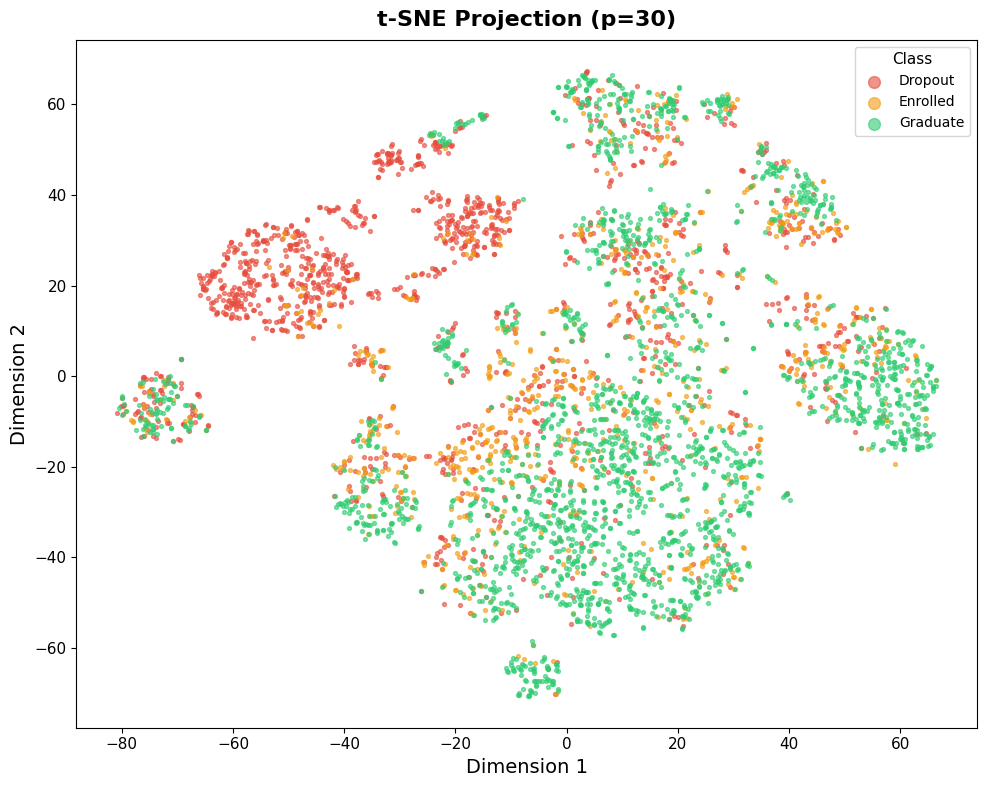

In [8]:
embedding_2d = results_2d[30]
save_path = os.path.join(project_root, "data", "plots", f"03_tsne_2d_perplexity_best.png")
plot_tsne_2d(embedding_2d, y.values, save_path=save_path)
plt.show()

## 3. 3D Projection

3D t-SNE:
t-SNE done: perplexity=30, n_components=3, shape=(4424, 3)
  Time elapsed: 13.9s
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/05_tsne_3d_best.png


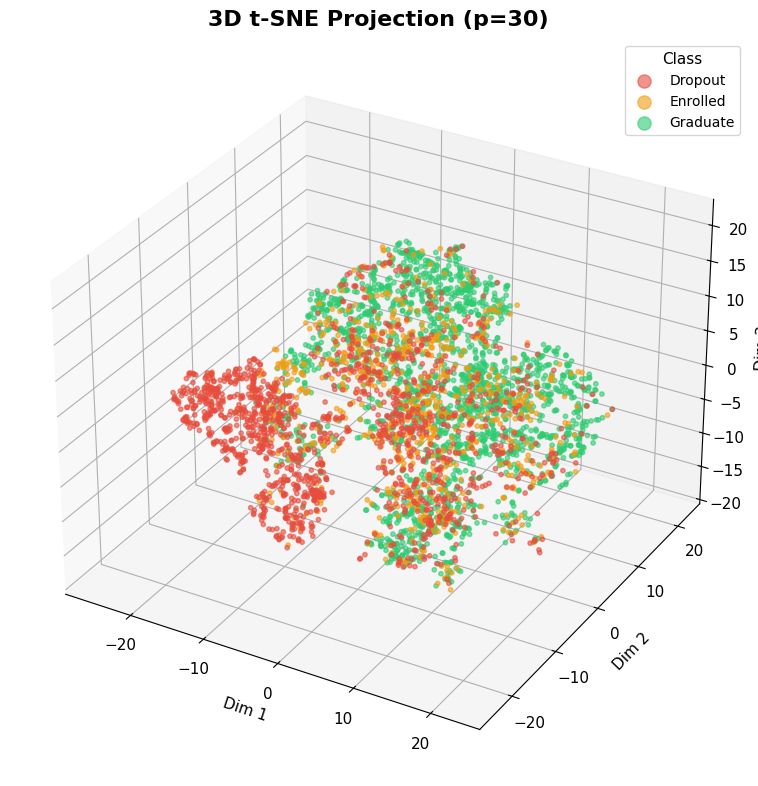

In [ ]:
# Compute and plot 3D t-SNE
best_perp = 30
print("3D t-SNE:")
start = time.time()
embedding_3d = compute_tsne(X.values, perplexity=best_perp, n_components=3)
print(f"  Time elapsed: {time.time() - start:.1f}s")

save_path_3d = os.path.join(project_root, "data", "plots", "05_tsne_3d_best.png")
fig_3d = plot_tsne_3d(embedding_3d, y.values, perplexity=best_perp, save_path=save_path_3d)
plt.show()

<!-- ## 6. Pattern Analysis

1. **Class Separability**: Graduate and Dropout form distinct regions in t-SNE space. Enrolled students are dispersed between both groups.

2. **Effect of Perplexity**:
   - Low perplexity (5): Fragmented, local structure emphasized.
   - Medium perplexity (30): Best balance; Graduate and Dropout form identifiable clusters.
   - High perplexity (50, 100): Over-smooths manifold; loss of detail.

3. **2D vs 3D**: 3D projection provides additional separation but is less suitable for static reports. -->